### Exercício 7

In [ ]:
# Instalando as bibliotecas necessárias para a execução otimizada da simulação
!pip install numba

In [14]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time
import scipy.stats as stats

Resultados do Método NBM (Batch Means)
Cenário    | d (Transiente)  | N Final    | Espera Sim.     | Espera Teo.     | H (Erro)  
λ = 7.0    | 340             | 115200     | 0.2290          | 0.2333          | 0.0102    
λ = 8.0    | 430             | 172710     | 0.3977          | 0.4000          | 0.0178    
λ = 9.0    | 550             | 581970     | 0.8828          | 0.9000          | 0.0364    
λ = 9.5    | 0               | 2943380    | 1.9414          | 1.9000          | 0.0761    


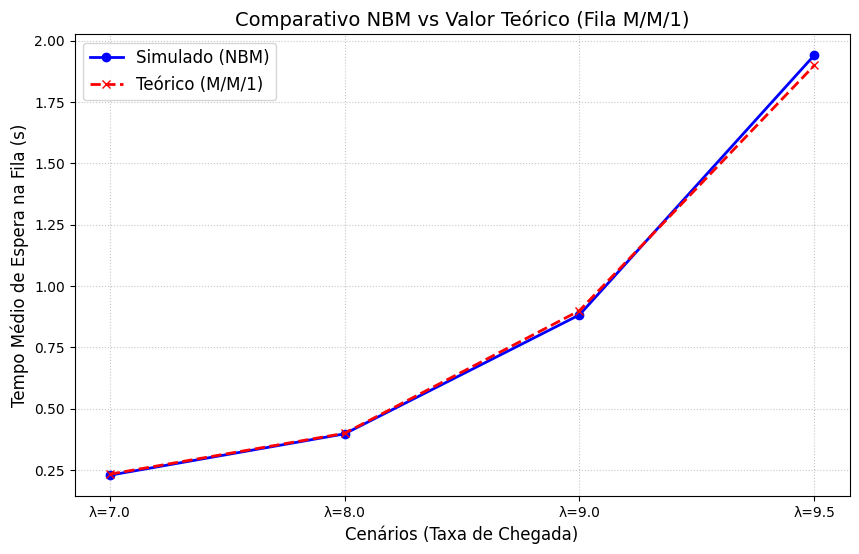

In [3]:
# 1. SIMULADOR DA FILA M/M/1
@jit(nopython=True)
def gerar_amostras_mm1(n_amostras, lambd, mu):
    esperas = np.zeros(n_amostras)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0
    beta_c = 1.0 / lambd
    beta_s = 1.0 / mu
    
    for i in range(n_amostras):
        tc = -beta_c * math.log(1.0 - random.random())
        t_chegada_atual += tc
        ts = -beta_s * math.log(1.0 - random.random())
        
        espera = max(0.0, t_saida_anterior - t_chegada_atual)
        esperas[i] = espera
        t_saida_anterior = t_chegada_atual + espera + ts
        
    return esperas

# 2. HEURÍSTICA MSER-5Y (Corte do Transiente)
def mser_5y(dados):
    # Agrupa em blocos de 5 para suavizar
    b_size = 5
    n_blocos = len(dados) // b_size
    blocos = np.mean(dados[:n_blocos * b_size].reshape(-1, b_size), axis=1)
    
    mser_vals = np.zeros(n_blocos // 2) # Testa cortes até a metade
    
    for d in range(len(mser_vals)):
        dados_truncados = blocos[d:]
        erro_padrao = np.std(dados_truncados, ddof=1) / math.sqrt(len(dados_truncados))
        mser_vals[d] = erro_padrao
        
    d_opt_bloco = np.argmin(mser_vals)
    d_opt_obs = d_opt_bloco * b_size
    return d_opt_obs

# 3. TESTE DE RANK VON NEUMANN (RVN)
def calcular_rvn(medias_blocos):
    B = len(medias_blocos)
    # Assinalar os ranks (1 a B)
    ranks = np.argsort(np.argsort(medias_blocos)) + 1 
    R_mean = np.mean(ranks)
    
    soma_diff_sq = np.sum((ranks[:-1] - ranks[1:])**2)
    soma_var_sq = np.sum((ranks - R_mean)**2)
    
    rvn = soma_diff_sq / soma_var_sq
    return rvn

# 4. ALGORITMO NBM COMPLETO
def executar_nbm(lambd, mu, B=20, beta_critico=1.44, precisao_alvo=0.05):
    # Passo inicial: gerar um lote grande para achar o transiente
    amostras_iniciais = gerar_amostras_mm1(20000, lambd, mu)
    d_transiente = mser_5y(amostras_iniciais)
    
    M = 100 # Tamanho inicial do bloco
    
    while True:
        N_necessario = d_transiente + (B * M)
        dados = gerar_amostras_mm1(N_necessario, lambd, mu)
        
        # Elimina o transiente
        dados_estacionarios = dados[d_transiente:]
        
        # Cria os B blocos de tamanho M
        blocos = dados_estacionarios[:B*M].reshape(B, M)
        Y = np.mean(blocos, axis=1) # Médias dos blocos
        
        # Teste de Correlação (RVN)
        rvn = calcular_rvn(Y)
        
        if rvn <= beta_critico:
            # Falhou no teste de independência, correlação ainda é alta
            M = int(M * 1.5) # Aumenta M
            continue
            
        # Passou no RVN, os blocos são independentes. Fase de Estimação:
        media_global = np.mean(Y)
        variancia_Y = np.var(Y, ddof=1)
        
        # t-student para B-1 graus de liberdade e alpha/2 = 0.025 (95% IC) -> t approx 2.093 para B=20
        t_val = 2.093 
        H = t_val * math.sqrt(variancia_Y / B)
        
        precisao_relativa = H / media_global if media_global > 0 else 1.0
        
        if precisao_relativa <= precisao_alvo:
            return d_transiente, M, B*M, media_global, H, precisao_relativa
        else:
            # Precisão não alcançada, aumentar M
            M = int(M * 1.5)

# 5. EXECUÇÃO DOS 4 CENÁRIOS
cenarios = [7.0, 8.0, 9.0, 9.5]
mu = 10.0
resultados_medias = []
esperado_teorico = []

print("Resultados do Método NBM (Batch Means)")
print(f"{'Cenário':<10} | {'d (Transiente)':<15} | {'N Final':<10} | {'Espera Sim.':<15} | {'Espera Teo.':<15} | {'H (Erro)':<10}")

for lambd in cenarios:
    t0 = time.time()
    rho = lambd / mu
    w_teorico = lambd / (mu * (mu - lambd))
    esperado_teorico.append(w_teorico)
    
    d, M_final, N_estacionario, media, H, precisao = executar_nbm(lambd, mu)
    
    resultados_medias.append(media)
    
    print(f"λ = {lambd:<6} | {d:<15} | {N_estacionario+d:<10} | {media:<15.4f} | {w_teorico:<15.4f} | {H:<10.4f}")

# 6. PLOTAGEM DO GRÁFICO COMPARATIVO
plt.figure(figsize=(10, 6))
x_labels = [f"λ={l}" for l in cenarios]

plt.plot(x_labels, resultados_medias, marker='o', label='Simulado (NBM)', linewidth=2, color='blue')
plt.plot(x_labels, esperado_teorico, marker='x', linestyle='--', label='Teórico (M/M/1)', linewidth=2, color='red')

plt.title('Comparativo NBM vs Valor Teórico (Fila M/M/1)', fontsize=14)
plt.xlabel('Cenários (Taxa de Chegada)', fontsize=12)
plt.ylabel('Tempo Médio de Espera na Fila (s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Exercício 8

In [19]:
# 1. FUNÇÕES BASE (Simulador, MSER-5Y, RVN)
@jit(nopython=True)
def gerar_amostras_mm1(n_amostras, lambd, mu):
    esperas = np.zeros(n_amostras)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0
    beta_c = 1.0 / lambd
    beta_s = 1.0 / mu
    
    for i in range(n_amostras):
        tc = -beta_c * math.log(1.0 - random.random())
        t_chegada_atual += tc
        ts = -beta_s * math.log(1.0 - random.random())
        
        espera = max(0.0, t_saida_anterior - t_chegada_atual)
        esperas[i] = espera
        t_saida_anterior = t_chegada_atual + espera + ts
        
    return esperas

def mser_5y(dados):
    b_size = 5
    n_blocos = len(dados) // b_size
    blocos = np.mean(dados[:n_blocos * b_size].reshape(-1, b_size), axis=1)
    
    mser_vals = np.zeros(n_blocos // 2)
    for d in range(len(mser_vals)):
        dados_truncados = blocos[d:]
        erro_padrao = np.std(dados_truncados, ddof=1) / math.sqrt(len(dados_truncados))
        mser_vals[d] = erro_padrao
        
    return np.argmin(mser_vals) * b_size

def calcular_rvn(medias_blocos):
    ranks = np.argsort(np.argsort(medias_blocos)) + 1 
    R_mean = np.mean(ranks)
    soma_diff_sq = np.sum((ranks[:-1] - ranks[1:])**2)
    soma_var_sq = np.sum((ranks - R_mean)**2)
    return soma_diff_sq / soma_var_sq

# 2. ALGORITMO SBM (Spaced Batch Means)
def executar_sbm(lambd, mu, regra_S, B=20, beta_critico=1.44, precisao_alvo=0.05):
    amostras_iniciais = gerar_amostras_mm1(20000, lambd, mu)
    d_transiente = mser_5y(amostras_iniciais)
    M = 100 
    
    while True:
        N_necessario = d_transiente + (B * M)
        dados = gerar_amostras_mm1(N_necessario, lambd, mu)
        dados_estacionarios = dados[d_transiente:]
        
        # Determina o valor de S baseado na regra
        if regra_S == '1':
            S = 1
        elif regra_S == 'M/10':
            S = max(1, int(M / 10))
            
        # Cria os blocos e descarta os S últimos elementos do cálculo da média
        blocos = dados_estacionarios[:B*M].reshape(B, M)
        Y = np.mean(blocos[:, :M-S], axis=1) 
        
        rvn = calcular_rvn(Y)
        
        if rvn <= beta_critico:
            M = int(M * 1.5)
            continue
            
        media_global = np.mean(Y)
        variancia_Y = np.var(Y, ddof=1)
        t_val = 2.093 # T-student 95% para B=20
        H = t_val * math.sqrt(variancia_Y / B)
        
        precisao_relativa = H / media_global if media_global > 0 else 1.0
        
        if precisao_relativa <= precisao_alvo:
            return d_transiente, M, B*M, S, media_global, H
        else:
            M = int(M * 1.5)

# 3. EXECUÇÃO
cenarios = [7.0, 8.0, 9.0, 9.5]
mu = 10.0
regras_S = ['1', 'M/10']

resultados_grafico = {'1': [], 'M/10': []}
teorico_grafico = []

for regra in regras_S:
    print(f"\nResultados SBM | Regra S = {regra}")
    print(f"{'Cenário':<8} | {'d (Trans)':<10} | {'N Final':<10} | {'S usado':<8} | {'Esp. Sim.':<10} | {'Esp. Teo.':<10} | {'H (Erro)'}")
    print("-" * 80)
    
    for lambd in cenarios:
        rho = lambd / mu
        w_teorico = lambd / (mu * (mu - lambd))
        
        if regra == '1':
            teorico_grafico.append(w_teorico)
            
        d, M_final, N_estacionario, S_usado, media, H = executar_sbm(lambd, mu, regra)
        resultados_grafico[regra].append(media)
        
        print(f"λ = {lambd:<4} | {d:<10} | {N_estacionario+d:<10} | {S_usado:<8} | {media:<10.4f} | {w_teorico:<10.4f} | {H:<.4f}")


Resultados SBM | Regra S = 1
Cenário  | d (Trans)  | N Final    | S usado  | Esp. Sim.  | Esp. Teo.  | H (Erro)
--------------------------------------------------------------------------------
λ = 7.0  | 0          | 76580      | 1        | 0.2363     | 0.2333     | 0.0104
λ = 8.0  | 570        | 258990     | 1        | 0.3864     | 0.4000     | 0.0101
λ = 9.0  | 2605       | 874725     | 1        | 0.8943     | 0.9000     | 0.0400
λ = 9.5  | 0          | 4415060    | 1        | 1.8740     | 1.9000     | 0.0795

Resultados SBM | Regra S = M/10
Cenário  | d (Trans)  | N Final    | S usado  | Esp. Sim.  | Esp. Teo.  | H (Erro)
--------------------------------------------------------------------------------
λ = 7.0  | 205        | 76785      | 382      | 0.2289     | 0.2333     | 0.0105
λ = 8.0  | 1075       | 259495     | 1292     | 0.4080     | 0.4000     | 0.0197
λ = 9.0  | 410        | 1308590    | 6540     | 0.8982     | 0.9000     | 0.0439
λ = 9.5  | 1580       | 2944960    | 14716

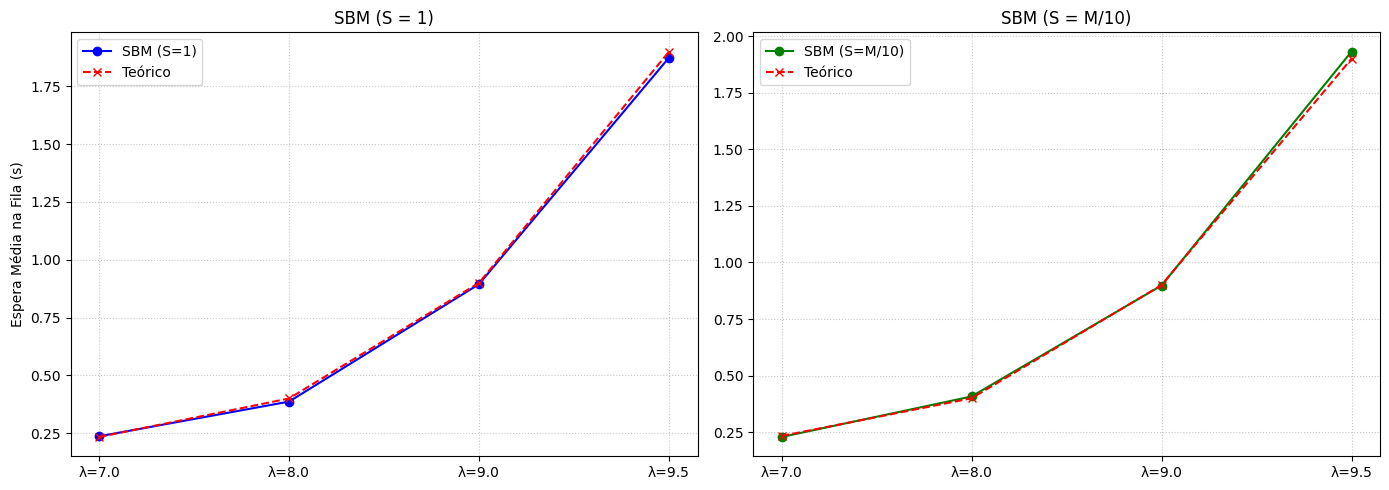

In [24]:
# 4. PLOTAGEM DOS GRÁFICOS
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [f"λ={l}" for l in cenarios]

# Gráfico para S = 1
axs[0].plot(x_labels, resultados_grafico['1'], marker='o', color='blue', label='SBM (S=1)')
axs[0].plot(x_labels, teorico_grafico, marker='x', linestyle='--', color='red', label='Teórico')
axs[0].set_title('SBM (S = 1)')
axs[0].set_ylabel('Espera Média na Fila (s)')
axs[0].grid(True, linestyle=':', alpha=0.7)
axs[0].legend()
# Gráfico para S = M/10
axs[1].plot(x_labels, resultados_grafico['M/10'], marker='o', color='green', label='SBM (S=M/10)')
axs[1].plot(x_labels, teorico_grafico, marker='x', linestyle='--', color='red', label='Teórico')
axs[1].set_title('SBM (S = M/10)')
axs[1].grid(True, linestyle=':', alpha=0.7)
axs[1].legend()

plt.tight_layout()
plt.show()

### Exercício 9


RESULTADOS OBM | Overlap = 100%
Cenário  | N Final    | M (Bloco)  | B (Janelas)  | Esp. Sim.  | Esp. Teo.  | H (Erro)
-------------------------------------------------------------------------------------
λ = 7.0  | 2000       | 100        | 1901         | 0.2170     | 0.2333     | 0.0064
λ = 8.0  | 3000       | 150        | 2851         | 0.4596     | 0.4000     | 0.0097
λ = 9.0  | 3000       | 150        | 2851         | 0.6762     | 0.9000     | 0.0191
λ = 9.5  | 15140      | 757        | 14384        | 1.3155     | 1.9000     | 0.0119

RESULTADOS OBM | Overlap = 50%
Cenário  | N Final    | M (Bloco)  | B (Janelas)  | Esp. Sim.  | Esp. Teo.  | H (Erro)
-------------------------------------------------------------------------------------
λ = 7.0  | 50600      | 100        | 1009         | 0.2403     | 0.2333     | 0.0105
λ = 8.0  | 50500      | 100        | 1009         | 0.3721     | 0.4000     | 0.0176
λ = 9.0  | 176595     | 225        | 1519         | 0.8938     | 0.9000     | 0

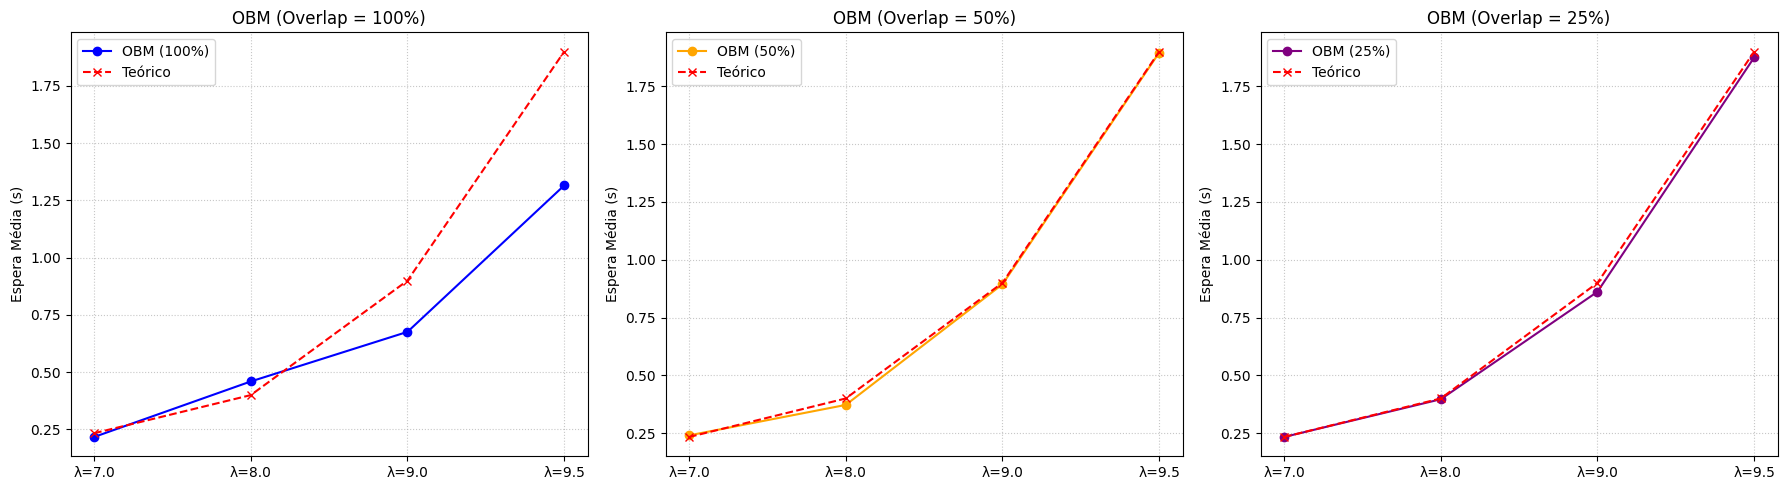

In [9]:
# 1. FUNÇÕES BASE
@jit(nopython=True)
def gerar_amostras_mm1(n_amostras, lambd, mu):
    esperas = np.zeros(n_amostras)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0
    beta_c = 1.0 / lambd
    beta_s = 1.0 / mu
    
    for i in range(n_amostras):
        tc = -beta_c * math.log(1.0 - random.random())
        t_chegada_atual += tc
        ts = -beta_s * math.log(1.0 - random.random())
        
        espera = max(0.0, t_saida_anterior - t_chegada_atual)
        esperas[i] = espera
        t_saida_anterior = t_chegada_atual + espera + ts
        
    return esperas

def mser_5y(dados):
    b_size = 5
    n_blocos = len(dados) // b_size
    blocos = np.mean(dados[:n_blocos * b_size].reshape(-1, b_size), axis=1)
    
    mser_vals = np.zeros(n_blocos // 2)
    for d in range(len(mser_vals)):
        dados_truncados = blocos[d:]
        erro_padrao = np.std(dados_truncados, ddof=1) / math.sqrt(len(dados_truncados))
        mser_vals[d] = erro_padrao
        
    return np.argmin(mser_vals) * b_size

def calcular_rvn(medias_blocos):
    ranks = np.argsort(np.argsort(medias_blocos)) + 1 
    R_mean = np.mean(ranks)
    soma_diff_sq = np.sum((ranks[:-1] - ranks[1:])**2)
    soma_var_sq = np.sum((ranks - R_mean)**2)
    return soma_diff_sq / soma_var_sq

# 2. ALGORITMO OBM (Overlapping Batch Means)
def executar_obm(lambd, mu, overlap_pct, beta_critico=1.44, precisao_alvo=0.05):
    # Aquecimento e MSER
    amostras_iniciais = gerar_amostras_mm1(20000, lambd, mu)
    d_transiente = mser_5y(amostras_iniciais)
    
    M = 100 
    B_base = 20
    
    # Fase 1: Achar o M mínimo usando NBM (sem superposição) para garantir independência inicial
    while True:
        N_teste = d_transiente + (B_base * M)
        dados = gerar_amostras_mm1(N_teste, lambd, mu)[d_transiente:]
        Y_teste = np.mean(dados[:B_base*M].reshape(B_base, M), axis=1)
        
        if calcular_rvn(Y_teste) > beta_critico:
            break # Encontramos o M onde a correlação foi quebrada
        M = int(M * 1.5)

    # Fase 2: Estimação usando OBM com o M encontrado
    while True:
        N = B_base * M
        dados = gerar_amostras_mm1(d_transiente + N, lambd, mu)[d_transiente:]
        
        # Define o passo de deslizamento com base na % de overlap
        if overlap_pct == 1.0:
            step = 1                # 100% overlap
        elif overlap_pct == 0.5:
            step = max(1, int(M * 0.5))  # 50% overlap
        elif overlap_pct == 0.25:
            step = max(1, int(M * 0.75)) # 25% overlap (pula 75%)
            
        # Cria as janelas deslizantes (Overlapping Blocks)
        Y_overlapping = []
        for i in range(0, N - M + 1, step):
            Y_overlapping.append(np.mean(dados[i : i + M]))
            
        Y = np.array(Y_overlapping)
        B_linha = len(Y)
        
        media_global = np.mean(Y)
        variancia_Y = np.var(Y, ddof=1)
        
        # Aproximação Normal para grandes amostras (>30)
        t_val = 1.96 
        H = t_val * math.sqrt(variancia_Y / B_linha)
        
        precisao_relativa = H / media_global if media_global > 0 else 1.0
        
        if precisao_relativa <= precisao_alvo:
            return d_transiente, M, N, B_linha, media_global, H
        else:
            B_base = int(B_base * 1.5) # Aumenta a quantidade de dados gerados

# 3. EXECUÇÃO
cenarios = [7.0, 8.0, 9.0, 9.5]
mu = 10.0
overlaps = [1.0, 0.5, 0.25]
nomes_overlap = {1.0: '100%', 0.5: '50%', 0.25: '25%'}

resultados_grafico = {1.0: [], 0.5: [], 0.25: []}
teorico_grafico = []

for ov in overlaps:
    print(f"\nRESULTADOS OBM | Overlap = {nomes_overlap[ov]}")
    print(f"{'Cenário':<8} | {'N Final':<10} | {'M (Bloco)':<10} | {'B (Janelas)':<12} | {'Esp. Sim.':<10} | {'Esp. Teo.':<10} | {'H (Erro)'}")
    print("-" * 85)
    
    for lambd in cenarios:
        w_teorico = lambd / (mu * (mu - lambd))
        if ov == 1.0:
            teorico_grafico.append(w_teorico)
            
        d, M_final, N_final, B_linha, media, H = executar_obm(lambd, mu, ov)
        resultados_grafico[ov].append(media)
        
        print(f"λ = {lambd:<4} | {N_final+d:<10} | {M_final:<10} | {B_linha:<12} | {media:<10.4f} | {w_teorico:<10.4f} | {H:<.4f}")

# 4. PLOTAGEM DOS GRÁFICOS
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
x_labels = [f"λ={l}" for l in cenarios]
colors = {1.0: 'blue', 0.5: 'orange', 0.25: 'purple'}

for idx, ov in enumerate(overlaps):
    axs[idx].plot(x_labels, resultados_grafico[ov], marker='o', color=colors[ov], label=f'OBM ({nomes_overlap[ov]})')
    axs[idx].plot(x_labels, teorico_grafico, marker='x', linestyle='--', color='red', label='Teórico')
    axs[idx].set_title(f'OBM (Overlap = {nomes_overlap[ov]})')
    axs[idx].set_ylabel('Espera Média (s)')
    axs[idx].grid(True, linestyle=':', alpha=0.7)
    axs[idx].legend()

plt.tight_layout()
plt.show()

### Exercício 10

RESULTADOS DO MÉTODO STS/AREA
Cenário  | d (Trans)  | N Final    | M (Bloco)  | Esp. Sim.  | Esp. Teo.  | H (Erro)
--------------------------------------------------------------------------------
λ = 7.0  | 410        | 76580      | 3829       | 0.2246     | 0.2333     | 0.0071
λ = 8.0  | 0          | 258420     | 12921      | 0.4133     | 0.4000     | 0.0202
λ = 9.0  | 595        | 872120     | 43606      | 0.9249     | 0.9000     | 0.0436
λ = 9.5  | 4905       | 1308180    | 65409      | 1.9499     | 1.9000     | 0.0910


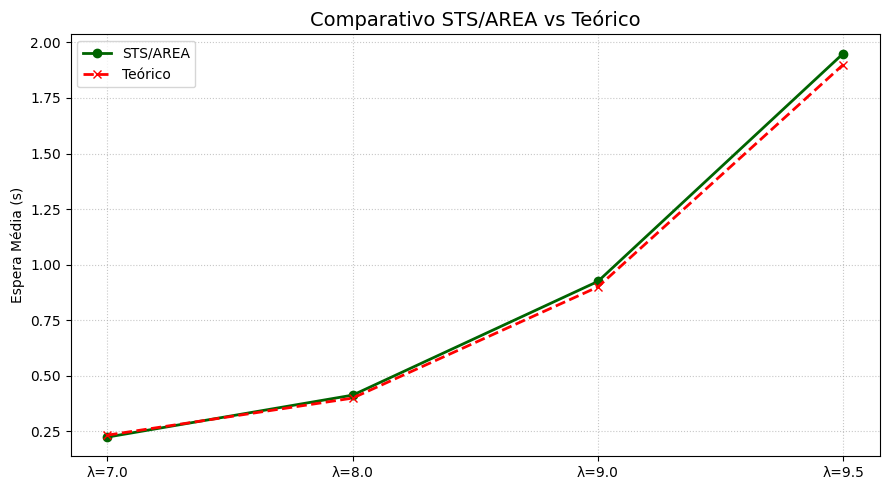

In [15]:
# 1. FUNÇÕES BASE (Simulador e MSER-5Y)
@jit(nopython=True)
def gerar_amostras_mm1(n_amostras, lambd, mu):
    esperas = np.zeros(n_amostras)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0
    beta_c = 1.0 / lambd
    beta_s = 1.0 / mu
    
    for i in range(n_amostras):
        tc = -beta_c * math.log(1.0 - random.random())
        t_chegada_atual += tc
        ts = -beta_s * math.log(1.0 - random.random())
        
        espera = max(0.0, t_saida_anterior - t_chegada_atual)
        esperas[i] = espera
        t_saida_anterior = t_chegada_atual + espera + ts
        
    return esperas

def mser_5y(dados):
    b_size = 5
    n_blocos = len(dados) // b_size
    blocos = np.mean(dados[:n_blocos * b_size].reshape(-1, b_size), axis=1)
    
    mser_vals = np.zeros(n_blocos // 2)
    for d in range(len(mser_vals)):
        dados_truncados = blocos[d:]
        erro_padrao = np.std(dados_truncados, ddof=1) / math.sqrt(len(dados_truncados))
        mser_vals[d] = erro_padrao
        
    return np.argmin(mser_vals) * b_size

# 2. ALGORITMO STS / AREA
def executar_sts_area(lambd, mu, B=20, precisao_alvo=0.05):
    # Aquecimento
    amostras_iniciais = gerar_amostras_mm1(20000, lambd, mu)
    d_transiente = mser_5y(amostras_iniciais)
    
    M = 100 
    
    # Fase 1: Encontrar M que garanta a Normalidade (Shapiro-Wilk)
    while True:
        N = B * M
        dados = gerar_amostras_mm1(d_transiente + N, lambd, mu)[d_transiente:]
        blocos = dados[:N].reshape(B, M)
        
        # Calcula os pesos ( (M+1)/2 - j ) para j de 1 a M
        j = np.arange(1, M + 1)
        w = (M + 1) / 2.0 - j
        
        # Calcula o representante Ai para cada bloco (produto escalar com os pesos)
        A = np.dot(blocos, w)
        
        # Teste de Shapiro-Wilk para Normalidade
        stat, p_value = stats.shapiro(A)
        
        if p_value > 0.05:
            break # Passou no teste! A distribuição é aproximadamente Normal.
        else:
            M = int(M * 1.5) # Aumenta M e tenta de novo

    # Fase 2: Estimação até atingir a precisão alvo
    while True:
        N = B * M
        dados = gerar_amostras_mm1(d_transiente + N, lambd, mu)[d_transiente:]
        blocos = dados[:N].reshape(B, M)
        
        j = np.arange(1, M + 1)
        w = (M + 1) / 2.0 - j
        A = np.dot(blocos, w)
        
        media_global = np.mean(dados)
        
        # Cálculo de H_A conforme a fórmula de STS/AREA
        A_sq_sum = np.sum(A**2)
        t_val = stats.t.ppf(0.975, B) # t-student para graus de liberdade = B, alpha=0.05
        
        # inner_term = 12 * sum(Ai^2) / (N^2 * (M^2 - 1))
        inner_term = (12.0 * A_sq_sum) / ((N**2) * (M**2 - 1.0))
        H_A = t_val * math.sqrt(inner_term)
        
        precisao_relativa = H_A / media_global if media_global > 0 else 1.0
        
        if precisao_relativa <= precisao_alvo:
            return d_transiente, M, N, media_global, H_A
        else:
            M = int(M * 1.5)

# 3. EXECUÇÃO
cenarios = [7.0, 8.0, 9.0, 9.5]
mu = 10.0

resultados_medias = []
esperado_teorico = []

print("RESULTADOS DO MÉTODO STS/AREA")
print(f"{'Cenário':<8} | {'d (Trans)':<10} | {'N Final':<10} | {'M (Bloco)':<10} | {'Esp. Sim.':<10} | {'Esp. Teo.':<10} | {'H (Erro)'}")
print("-" * 80)

for lambd in cenarios:
    rho = lambd / mu
    w_teorico = lambd / (mu * (mu - lambd))
    esperado_teorico.append(w_teorico)
    
    d, M_final, N_final, media, H = executar_sts_area(lambd, mu)
    resultados_medias.append(media)
    
    print(f"λ = {lambd:<4} | {d:<10} | {N_final:<10} | {M_final:<10} | {media:<10.4f} | {w_teorico:<10.4f} | {H:<.4f}")

# 4. PLOTAGEM DO GRÁFICO
plt.figure(figsize=(9, 5))
x_labels = [f"λ={l}" for l in cenarios]

plt.plot(x_labels, resultados_medias, marker='o', label='STS/AREA', linewidth=2, color='darkgreen')
plt.plot(x_labels, esperado_teorico, marker='x', linestyle='--', label='Teórico', linewidth=2, color='red')

plt.title('Comparativo STS/AREA vs Teórico', fontsize=14)
plt.ylabel('Espera Média (s)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Exercício 11

RESULTADOS DO MÉTODO STS/CSUM
Cenário  | d (Trans)  | N Final    | M (Bloco)  | Esp. Sim.  | Esp. Teo.  | H (Erro)
--------------------------------------------------------------------------------
λ = 7.0  | 1160       | 172280     | 8614       | 0.2343     | 0.2333     | 0.0105
λ = 8.0  | 0          | 258420     | 12921      | 0.3923     | 0.4000     | 0.0174
λ = 9.0  | 0          | 581420     | 29071      | 0.8778     | 0.9000     | 0.0388
λ = 9.5  | 5580       | 1962260    | 98113      | 1.8661     | 1.9000     | 0.0870


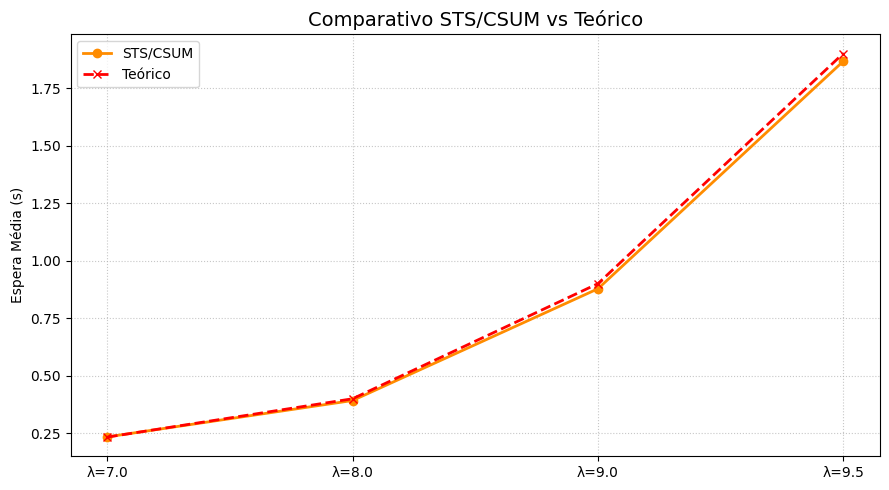

In [16]:
# 1. FUNÇÕES BASE
@jit(nopython=True)
def gerar_amostras_mm1(n_amostras, lambd, mu):
    esperas = np.zeros(n_amostras)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0
    beta_c = 1.0 / lambd
    beta_s = 1.0 / mu
    
    for i in range(n_amostras):
        tc = -beta_c * math.log(1.0 - random.random())
        t_chegada_atual += tc
        ts = -beta_s * math.log(1.0 - random.random())
        
        espera = max(0.0, t_saida_anterior - t_chegada_atual)
        esperas[i] = espera
        t_saida_anterior = t_chegada_atual + espera + ts
        
    return esperas

def mser_5y(dados):
    b_size = 5
    n_blocos = len(dados) // b_size
    blocos = np.mean(dados[:n_blocos * b_size].reshape(-1, b_size), axis=1)
    
    mser_vals = np.zeros(n_blocos // 2)
    for d in range(len(mser_vals)):
        dados_truncados = blocos[d:]
        erro_padrao = np.std(dados_truncados, ddof=1) / math.sqrt(len(dados_truncados))
        mser_vals[d] = erro_padrao
        
    return np.argmin(mser_vals) * b_size

# 2. ALGORITMO STS / CSUM
def executar_sts_csum(lambd, mu, B=20, precisao_alvo=0.05):
    amostras_iniciais = gerar_amostras_mm1(20000, lambd, mu)
    d_transiente = mser_5y(amostras_iniciais)
    
    M = 100 
    
    # Fase 1: Encontrar M que garanta a Normalidade (Shapiro-Wilk)
    while True:
        N = B * M
        dados = gerar_amostras_mm1(d_transiente + N, lambd, mu)[d_transiente:]
        blocos = dados[:N].reshape(B, M)
        
        j = np.arange(1, M + 1)
        w = (M + 1) / 2.0 - j
        A_i = np.dot(blocos, w)
        
        stat, p_value = stats.shapiro(A_i)
        if p_value > 0.05:
            break 
        else:
            M = int(M * 1.5)

    # Fase 2: Estimação usando as fórmulas do CSUM
    while True:
        N = B * M
        dados = gerar_amostras_mm1(d_transiente + N, lambd, mu)[d_transiente:]
        blocos = dados[:N].reshape(B, M)
        
        j = np.arange(1, M + 1)
        w = (M + 1) / 2.0 - j
        A_i = np.dot(blocos, w)
        
        X_i = np.mean(blocos, axis=1) # Médias dos blocos
        X_global = np.mean(dados)     # Média global
        
        # Fórmula da estatística A do CSUM
        # A = sum( 12 * Ai^2 / (M^3 - M) + M * (X_global - X_i)^2 )
        A_stat = np.sum( (12.0 * A_i**2) / (M**3 - M) + M * (X_global - X_i)**2 )
        
        # t-student com 2B - 1 graus de liberdade
        t_val = stats.t.ppf(0.975, 2 * B - 1) 
        
        # Fórmula do H_CSUM
        H_CSUM = t_val * math.sqrt(A_stat / (N * (2 * B - 1)))
        
        precisao_relativa = H_CSUM / X_global if X_global > 0 else 1.0
        
        if precisao_relativa <= precisao_alvo:
            return d_transiente, M, N, X_global, H_CSUM
        else:
            M = int(M * 1.5)

# 3. EXECUÇÃO
cenarios = [7.0, 8.0, 9.0, 9.5]
mu = 10.0

resultados_medias = []
esperado_teorico = []

print("RESULTADOS DO MÉTODO STS/CSUM")
print(f"{'Cenário':<8} | {'d (Trans)':<10} | {'N Final':<10} | {'M (Bloco)':<10} | {'Esp. Sim.':<10} | {'Esp. Teo.':<10} | {'H (Erro)'}")
print("-" * 80)

for lambd in cenarios:
    rho = lambd / mu
    w_teorico = lambd / (mu * (mu - lambd))
    esperado_teorico.append(w_teorico)
    
    d, M_final, N_final, media, H = executar_sts_csum(lambd, mu)
    resultados_medias.append(media)
    
    print(f"λ = {lambd:<4} | {d:<10} | {N_final:<10} | {M_final:<10} | {media:<10.4f} | {w_teorico:<10.4f} | {H:<.4f}")

# 4. PLOTAGEM DO GRÁFICO
plt.figure(figsize=(9, 5))
x_labels = [f"λ={l}" for l in cenarios]

plt.plot(x_labels, resultados_medias, marker='o', label='STS/CSUM', linewidth=2, color='darkorange')
plt.plot(x_labels, esperado_teorico, marker='x', linestyle='--', label='Teórico', linewidth=2, color='red')

plt.title('Comparativo STS/CSUM vs Teórico', fontsize=14)
plt.ylabel('Espera Média (s)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Exercício 12

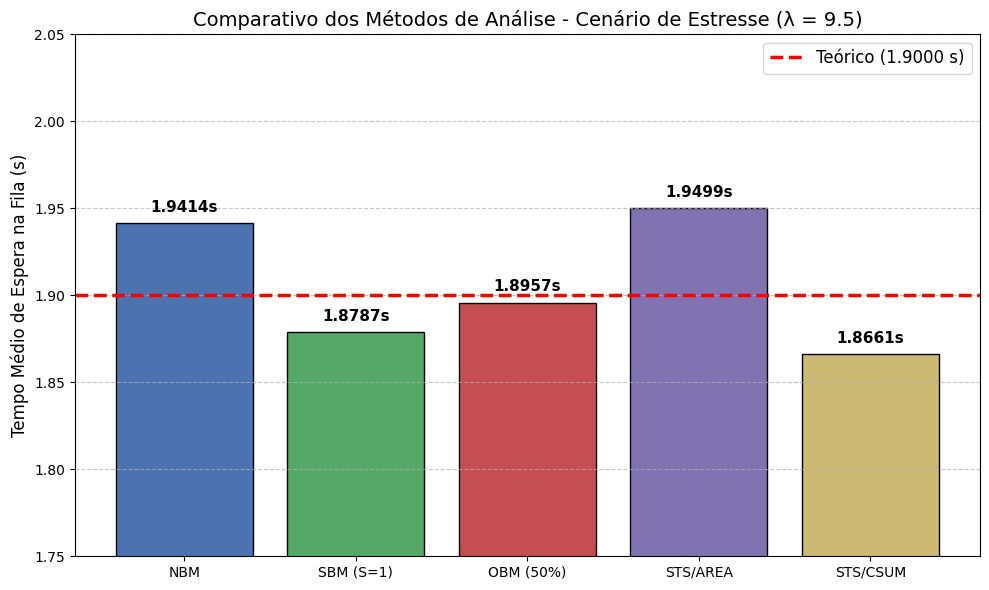

In [17]:
# Dados consolidados das simulações anteriores para o Cenário IV (lambda = 9.5)
metodos = ['NBM', 'SBM (S=1)', 'OBM (50%)', 'STS/AREA', 'STS/CSUM']
esperas_simuladas = [1.9414, 1.8787, 1.8957, 1.9499, 1.8661]
espera_teorica = 1.9000

plt.figure(figsize=(10, 6))

# Criação do gráfico de barras
bars = plt.bar(metodos, esperas_simuladas, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'], edgecolor='black')

# Linha horizontal para o valor teórico esperado
plt.axhline(y=espera_teorica, color='red', linestyle='--', linewidth=2.5, label=f'Teórico ({espera_teorica:.4f} s)')

# Adicionando os valores em cima de cada barra para clareza visual
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ajustes estéticos (limitando o eixo Y para dar zoom na diferença)
plt.title('Comparativo dos Métodos de Análise - Cenário de Estresse (λ = 9.5)', fontsize=14)
plt.ylabel('Tempo Médio de Espera na Fila (s)', fontsize=12)
plt.ylim(1.75, 2.05) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()